## 1. Process dataset

Load and read dataset and transpose it 

In [102]:
import pandas as pd

json_path = "data/games.json"

df_original = pd.read_json(json_path, orient="index")
df_original.index.name = "app_id"

print(df_original.dtypes)
print(df_original.shape)

name                            str
release_date                    str
required_age                  int64
price                       float64
dlc_count                     int64
detailed_description            str
about_the_game                  str
short_description               str
reviews                         str
header_image                    str
website                         str
support_url                     str
support_email                   str
windows                        bool
mac                            bool
linux                          bool
metacritic_score              int64
metacritic_url                  str
achievements                  int64
recommendations               int64
notes                           str
supported_languages          object
full_audio_languages         object
packages                     object
developers                   object
publishers                   object
categories                   object
genres                      

Use a copy for DataFrame instead of touching the original

In [103]:
df = df_original.reset_index()
df.head()

,app_id,name,release_date,required_age,price,dlc_count,detailed_description,about_the_game,short_description,reviews,...,positive,negative,estimated_owners,average_playtime_forever,average_playtime_2weeks,median_playtime_forever,median_playtime_2weeks,discount,peak_ccu,tags
0,2539430,Black Dragon Mage Playtest,"Aug 1, 2023",0,0.00,0,,,,,...,0,0,0 - 0,0,0,0,0,0,0,[]
1,496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0,5.24,0,"Springtime, April: when the cherry trees come ...","Springtime, April: when the cherry trees come ...","Spring has come, and our protagonist, Yukinari...",,...,252,3,0 - 20000,8,0,8,0,65,0,"{'Adventure': 27, 'Visual Novel': 19, 'Anime':..."
2,1034400,Mystery Solitaire The Black Raven,"May 6, 2019",0,4.99,0,"Immerse yourself in the most beloved, mystical...","Immerse yourself in the most beloved, mystical...",Discover an entrancing and spectacular world!,,...,21,3,0 - 20000,0,0,0,0,0,0,"{'Casual': 83, 'Card Game': 52, 'Solitaire': 4..."
3,3292190,버튜버 파라노이아 - Vtuber Paranoia,"Oct 31, 2024",0,8.99,1,"synopsis 'Hello, I'm Hiyoro, a new YouTuber!' ...","synopsis 'Hello, I'm Hiyoro, a new YouTuber!' ...",Yuha! I'll start the broadcast! Hakko's extrem...,,...,0,0,0 - 20000,0,0,0,0,0,1,[]
4,3631080,Maze Quest VR,"Apr 24, 2025",0,4.99,0,Its not just a Maze; its a Quest! Enter the ca...,Its not just a Maze; its a Quest! Enter the ca...,Its not just a Maze; its a Quest! Enter the ca...,,...,0,0,0 - 20000,0,0,0,0,0,0,[]


In [104]:
# Basic Data Cleaning
df["name"] = df["name"].str.strip()
df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")

# Remove rows without names
df = df[df["name"].notna() & df["name"].ne("")]

# Remove rows without any metadata
metadata_columns = ["categories", "genres", "tags"]

has_metadata = (
    df[metadata_columns]
    .apply(lambda col: col.map(lambda x: isinstance(x, (list, dict)) and len(x) > 0))
    .any(axis=1)
)

df = df[has_metadata]

# Deduplicate rows
dedup_keys = ["name", "release_date", "detailed_description"]

df["null_count"] = df.isnull().sum(axis=1)

df = (
    df.sort_values(by=["null_count", "app_id"], ascending=[True, True])
    .drop_duplicates(subset=dedup_keys, keep="first")
    .drop(columns=["null_count"])
    .reset_index(drop=True)
)

# Drop unnecessary columns
columns_to_drop = [
    "required_age",
    "dlc_count",
    "detailed_description",
    "about_the_game",
    "reviews",
    "header_image",
    "website",
    "support_url",
    "support_email",
    "metacritic_url",
    "achievements",
    "notes",
    "supported_languages",
    "full_audio_languages",
    "packages",
    "screenshots",
    "movies",
    "user_score",
    "score_rank",
    "estimated_owners",
    "average_playtime_2weeks",
    "median_playtime_forever",
    "median_playtime_2weeks",
    "peak_ccu",
]
df = df.drop(columns=columns_to_drop, errors="ignore")

In [105]:
import re
import unicodedata

import numpy as np


# Text processing
def clean_text(text):
    text = str(text).casefold()
    text = unicodedata.normalize("NFD", text)
    text = "".join(c for c in text if unicodedata.category(c) != "Mn")
    text = re.sub(r"[']", "", text)
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def process_metadata(val):
    if isinstance(val, dict):
        raw_list = list(val.keys())
    elif isinstance(val, list):
        raw_list = val
    else:
        return []
    return [clean_text(item) for item in raw_list if str(item).strip()]


def wilson_score(positive, total, z=1.96):
    p = np.divide(
        positive, total, out=np.zeros_like(positive, dtype=float), where=total > 0
    )

    denominator = 1 + z**2 / total
    centre = p + z**2 / (2 * total)

    adjustment = z * np.sqrt((p * (1 - p) / total) + (z**2 / (4 * total**2)))

    return (centre - adjustment) / denominator


df["cleaned_name"] = df["name"].map(clean_text)

df["total_reviews"] = df["positive"] + df["negative"]
df["quality_score"] = wilson_score(df["positive"], df["total_reviews"])

df["cleaned_categories"] = df["categories"].map(process_metadata)
df["cleaned_genres"] = df["genres"].map(process_metadata)
df["cleaned_tags"] = df["tags"].map(process_metadata)

df["combined_metadata"] = (
    df["cleaned_categories"] + df["cleaned_genres"] + df["cleaned_tags"]
).map(lambda x: " ".join(dict.fromkeys(x)))

In [106]:
from sklearn.feature_extraction.text import TfidfVectorizer

title_vectorizer = TfidfVectorizer(
    stop_words="english", ngram_range=(1, 3), sublinear_tf=True, lowercase=False
)
title_matrix = title_vectorizer.fit_transform(df["cleaned_name"])

metadata_vectorizer = TfidfVectorizer(
    stop_words="english", ngram_range=(1, 2), sublinear_tf=True, lowercase=False
)
metadata_matrix = metadata_vectorizer.fit_transform(df["combined_metadata"])

## 2. Process intents

In [107]:
import json

intents_path = "data/intents.json"

with open(intents_path, "r") as f:
    data = json.load(f)

patterns, tags = [], []
responses_lookup = {}

for intent in data["intents"]:
    tag = intent["tag"]
    if intent.get("responses") is not None:
        responses_lookup[tag] = intent["responses"]

    for pattern in intent["patterns"]:
        patterns.append(clean_text(pattern))
        tags.append(tag)

In [108]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import FeatureUnion, Pipeline

model = Pipeline(
    [
        (
            "features",
            FeatureUnion(
                [
                    (
                        "word_vec",
                        TfidfVectorizer(
                            analyzer="word", ngram_range=(1, 2), lowercase=True
                        ),
                    ),
                    (
                        "char_vec",
                        TfidfVectorizer(
                            analyzer="char_wb", ngram_range=(3, 5), lowercase=True
                        ),
                    ),
                ]
            ),
        ),
        (
            "clf",
            LogisticRegression(
                C=1.0, max_iter=1000, random_state=42, class_weight="balanced"
            ),
        ),
    ]
)

model.fit(patterns, tags)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('features', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[<U16](8,)","['creator','game_info','goodbye',...,'platform_support','price_inquiry', 'recommendation']"
,"transformer_list transformer_list: list of (str, transformer) tuplesList of transformer objects to be applied to the data. The firsthalf of each tuple is the name of the transformer. The transformer canbe 'drop' for it to be ignored or can be 'passthrough' for features tobe passed unchanged... versionadded:: 1.1 Added the option `""passthrough""`... versionchanged:: 0.22 Deprecated `None` as a transformer in favor of 'drop'.","[('word_vec', ...), ('char_vec', ...)]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer.Keys are transformer names, values the weights.Raises ValueError if key not present in ``transformer_list``.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, default=TrueIf True, :meth:`get_feature_names_out` will prefix all feature nameswith the name of the transformer that generated that feature.If False, :meth:`get_feature_names_out` will not prefix any featurenames and will error if feature names are not unique... versionadded:: 1.5",True


In [109]:
from flashtext import KeywordProcessor
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

keyword_processor = KeywordProcessor(case_sensitive=False)

DOMAIN_STOPWORDS = {
    "exit",
    "quit",
    "bye",
    "goodbye",
    "help",
    "hi",
    "hello",
    "thanks",
    "thank you",
    "yes",
    "no",
    "game",
    "games",
    "play",
    "price",
    "info",
    "overview",
    "look",
    "good",
    "best",
    "top",
    "free",
    "recommend",
    "suggest",
    "run",
    "cost",
    "check",
    "show",
    "list",
    "tell",
    "what",
    "how",
}

RESERVED_WORDS = set(ENGLISH_STOP_WORDS).union(DOMAIN_STOPWORDS)

TITLE_LIST = [
    title
    for title in sorted(df["cleaned_name"].unique(), key=len, reverse=True)
    if title not in RESERVED_WORDS
]

metadata_columns = ["cleaned_categories", "cleaned_genres", "cleaned_tags"]
metadata_terms = set()
for columns in metadata_columns:
    for value in df[columns]:
        metadata_terms.update(item for item in value if isinstance(item, str))
metadata_terms = {term for term in metadata_terms if term}

METADATA_TERMS = sorted(metadata_terms, key=len, reverse=True)


for title in TITLE_LIST:
    keyword_processor.add_keyword(title, "game_title")


def mask_entities(clean_input):
    matches = keyword_processor.extract_keywords(clean_input, span_info=True)

    if not matches:
        return clean_input, None

    longest_match = max(matches, key=lambda m: m[2] - m[1])
    _, start, end = longest_match

    extracted_title = clean_input[start:end]
    masked_text = clean_input[:start] + "game_title" + clean_input[end:]

    return masked_text, extracted_title


def get_intent(
    clean_input, confidence_threshold=0.40, margin_threshold=0.10, verbose=False
):
    probabilities = model.predict_proba([clean_input])[0]
    sorted_idx = np.argsort(probabilities)[::-1]

    best_idx = sorted_idx[0]
    second_idx = sorted_idx[1]

    confidence = probabilities[best_idx]
    margin = probabilities[best_idx] - probabilities[second_idx]

    if verbose:
        print("\n--- Intent Probabilities ---")
        for idx in sorted_idx:
            intent_name = model.classes_[idx]
            prob = probabilities[idx]
            print(f"  {intent_name:<20}: {prob * 100:6.2f}%")
        print(
            f"  Top Confidence: {confidence * 100:.2f}% | Margin: {margin * 100:.2f}%"
        )
        print("-----------------------------\n")

    if confidence < confidence_threshold and margin < margin_threshold:
        if verbose:
            print("[!] Intent rejected: Below confidence or margin threshold.")
        return None

    return model.classes_[best_idx]

In [111]:
from sklearn.metrics.pairwise import cosine_similarity


def extract_metadata(clean_input):
    return [
        term
        for term in METADATA_TERMS
        if re.search(rf"\b{re.escape(term)}\b", clean_input)
    ]


def find_by_title(parsed_query, similarity_threshold=0.15):
    title = parsed_query["title"]
    if title is None:
        return None

    exact_match = df[df["cleaned_name"] == title]
    if not exact_match.empty:
        return exact_match.iloc[0]

    query_vector = title_vectorizer.transform([title])
    similarities = cosine_similarity(query_vector, title_matrix).flatten()
    best_idx = np.argmax(similarities)
    if similarities[best_idx] < similarity_threshold:
        return None
    return df.iloc[best_idx]


def get_game_filter(
    metadata=None,
    max_price=None,
    platform=None,
    include_free=False,
    min_reviews=1000,
    min_quality=0.65,
):
    mask = (df["total_reviews"] > min_reviews) & (df["quality_score"] >= min_quality)

    if include_free:
        mask &= df["price"] == 0
    elif max_price is not None:
        mask &= df["price"] <= max_price

    if platform in ["windows", "mac", "linux"]:
        mask &= df[platform] == True

    if metadata:
        for term in metadata:
            mask &= df["combined_metadata"].str.contains(term, case=False, na=False)

    return mask


def find_similar_games(
    game, metadata=None, max_price=None, platform=None, include_free=False, top_n=5
):
    game_idx = game.name
    query_vector = metadata_matrix[game_idx]
    similarities = cosine_similarity(query_vector, metadata_matrix).flatten()

    mask = get_game_filter(
        metadata=metadata,
        max_price=max_price,
        platform=platform,
        include_free=include_free,
    )

    valid_indices = np.flatnonzero(mask)
    valid_indices = valid_indices[valid_indices != game_idx]

    if len(valid_indices) == 0:
        return pd.DataFrame()

    candidates = similarities[valid_indices]

    n = min(top_n, len(valid_indices))
    top_candidates = np.argpartition(candidates, -n)[-n:]
    top_candidates = top_candidates[np.argsort(-candidates[top_candidates])]
    return df.iloc[valid_indices[top_candidates]]


def filter_games(
    metadata=None,
    max_price=None,
    platform=None,
    top_n=5,
    sort_by="quality_score",
    include_free=False,
):
    mask = get_game_filter(
        metadata=metadata,
        max_price=max_price,
        platform=platform,
        include_free=include_free,
    )
    filtered_df = df.loc[mask]

    if filtered_df.empty:
        return pd.DataFrame()

    return filtered_df.sort_values(
        by=[sort_by, "recommendations"], ascending=False
    ).head(top_n)


def format_results(results, header):
    if results.empty:
        return "No games found based on your criteria."

    response = f"{header}"
    for _, row in results.iterrows():
        price = f"${row['price']:.2f}" if row["price"] > 0 else "Free"
        response += f"\n• {row['name']} - Price: {price} - Rating: {row['quality_score'] * 100:.1f}% ({row['total_reviews']:,} reviews)"
    return response


def handle_game_info(parsed_query):
    game = find_by_title(parsed_query)
    if game is None:
        return "I couldn't find that specific game in the database. Could you check the title and try again?"

    price = f"${game['price']:.2f}" if game["price"] > 0 else "Free"
    discount = f" ({game['discount']}% off)" if game["discount"] > 0 else ""
    developers = (
        ", ".join(game["developers"]) if len(game["developers"]) > 0 else "Unknown"
    )
    genres = ", ".join(game["genres"]) if len(game["genres"]) > 0 else "N/A"
    return (
        f"{game['name']}\n"
        f"Description: {game['short_description']}\n"
        f"Price: {price} {discount}\n"
        f"Developer(s): {developers}\n"
        f"Genre(s): {genres}\n"
        f"Rating Score: {game['quality_score'] * 100:.1f}% ({game['total_reviews']:,} reviews)"
    )


def handle_price_inquiry(parsed_query):
    game = find_by_title(parsed_query)
    if game is None:
        return "I couldn't identify the game you're asking about. Which game's price would you like to check?"

    discount = f" ({game['discount']}% off)" if game["discount"] > 0 else ""
    return f"{game['name']} is currently {f'priced at ${game['price']:.2f}{discount}.' if game['price'] > 0 else 'Free to Play!'}"


def handle_platform_support(parsed_query):
    if not parsed_query.get("title") and parsed_query.get("platform"):
        return handle_recommendation(
            parsed_query,
            header=f"Top rated games on {parsed_query['platform'].capitalize()}:",
        )

    game = find_by_title(parsed_query)
    if game is None:
        return "I couldn't identify the game you're asking about. Which game's platforms would you like to check?"

    platforms = [
        name
        for name, column in (
            ("Windows", "windows"),
            ("macOS", "mac"),
            ("Linux", "linux"),
        )
        if game[column]
    ]
    return (
        f"{game['name']} is available on: {', '.join(platforms)}"
        if platforms
        else f"{game['name']} is not available on Windows, Mac, or Linux."
    )


def handle_recommendation(parsed_query):
    if parsed_query.get("title"):
        game = find_by_title(parsed_query)
        if game is not None:
            similar_games = find_similar_games(
                game,
                metadata=parsed_query.get("metadata"),
                max_price=parsed_query.get("max_price"),
                platform=parsed_query.get("platform"),
                include_free=parsed_query.get("include_free"),
                top_n=parsed_query["top_n"],
            )
            if similar_games.empty:
                return "I couldn't find any games similar to that title."
            return format_results(similar_games, f"Games similar to {game['name']}:")

    games = filter_games(
        metadata=parsed_query.get("metadata"),
        max_price=parsed_query.get("max_price"),
        platform=parsed_query.get("platform"),
        top_n=parsed_query.get("top_n"),
        include_free=parsed_query.get("include_free"),
    )

    header = ["Recommended games"]
    if parsed_query.get("platform"):
        header.append(f"on {parsed_query['platform'].capitalize()}")
    if parsed_query.get("max_price") is not None:
        header.append(f"under ${parsed_query['max_price']:.2f}")
    if parsed_query.get("metadata"):
        header.append(f"matching {', '.join(parsed_query['metadata'])}")

    return format_results(games, f"{' '.join(header)}:")


def handle_response(parsed_query, intent):
    if intent == "game_info":
        return handle_game_info(parsed_query)
    elif intent == "recommendation":
        return handle_recommendation(parsed_query)
    elif intent == "platform_support":
        return handle_platform_support(parsed_query)
    elif intent == "price_inquiry":
        return handle_price_inquiry(parsed_query)
    elif intent in responses_lookup:
        return np.random.choice(responses_lookup[intent])


def parse_query(clean_input, title=None):
    include_free = "free" in clean_input

    result = {
        "title": title,
        "metadata": extract_metadata(clean_input),
        "max_price": None,
        "top_n": 5,
        "platform": None,
        "include_free": include_free,
    }

    numbers = re.findall(r"\d+(?:\.\d+)?", clean_input)
    if numbers:
        result["max_price"] = float(numbers[0])

    # Platform
    if re.search(r"\b(linux)\b", clean_input):
        result["platform"] = "linux"
    elif re.search(r"\b(mac(?:os)?)\b", clean_input):
        result["platform"] = "mac"
    elif re.search(r"\b(windows)\b", clean_input):
        result["platform"] = "windows"
    return result


def chat(raw_input):
    clean_input = clean_text(raw_input)
    masked_text, extracted_title = mask_entities(clean_input)
    intent = get_intent(masked_text)

    if intent is None:
        return "I'm sorry, I didn't quite catch that. Could you try rephrasing your request?"

    parsed_query = (
        parse_query(masked_text, title=extracted_title)
        if intent not in responses_lookup
        else None
    )
    return handle_response(parsed_query, intent)

In [112]:
import os

import joblib
from scipy.sparse import save_npz

os.makedirs("models", exist_ok=True)

joblib.dump(model, "models/intent_classifier.joblib")
joblib.dump(title_vectorizer, "models/title_vectorizer.joblib")
joblib.dump(metadata_vectorizer, "models/metadata_vectorizer.joblib")
joblib.dump(df, "models/games_data.joblib", compress=3)

save_npz("models/title_matrix.npz", title_matrix)
save_npz("models/metadata_matrix.npz", metadata_matrix)

auxiliary_data = {
    "responses_lookup": responses_lookup,
    "TITLE_LIST": TITLE_LIST,
    "METADATA_TERMS": list(METADATA_TERMS),
}
joblib.dump(auxiliary_data, "models/auxiliary_data.joblib")

['models/auxiliary_data.joblib']

In [ ]:
data = [
    "hi",
    "hello",
    "who developed you",
    "thank you for helping",
    "close",
    "exit",
    "give me information on baldurs gate 3",
    "info on baldurs gate 3",
    "look up terraria",
    "is terraria free",
    "is Team Fortress 2 free to play?",
    "is Manor Lords on sale?",
    "does terraria support linux",
    "can balatro run on windows",
    "is moonlighter supported on mac",
    "is Stardew Valley PC compatible?",
    "does brotato run on windows",
    "lookup brotato",
    "meccha chameleon",
    "recommed me good games",
]

data += [
    "what are the highest-rated games on Steam right now?",
    "recommend games like Portal 2",
    "games playable on linux",
    "recommend some action games",
    "games for mac?",
    "free games",
    "top free games on linux",
    "co op games for under $20",
    "games like terraria",
    "free games like holocure save the fans",
]


for text in data:
    clean_in = clean_text(text)
    masked_text, extracted_title = mask_entities(clean_in)
    intent = get_intent(masked_text)
    print(
        f"Masked Text: '{masked_text}'| Extracted Title: {extracted_title} | Intent: {intent}"
    )

    if intent is None:
        print(
            "I'm sorry, I didn't quite catch that. Could you try rephrasing your request?"
        )
        continue

    parsed_query = (
        parse_query(masked_text, title=extracted_title)
        if intent not in responses_lookup
        else None
    )
    print(f"{handle_response(parsed_query, intent)}\n")

Masked Text: 'give me information on game_title'| Extracted Title: baldurs gate 3 | Intent: game_info
Baldur's Gate 3
Description: Baldur’s Gate 3 is a story-rich, party-based RPG set in the universe of Dungeons &amp; Dragons, where your choices shape a tale of fellowship and betrayal, survival and sacrifice, and the lure of absolute power.
Price: $44.99  (25% off)
Developer(s): Larian Studios
Genre(s): Adventure, RPG, Strategy
Rating Score: 96.8% (760662 reviews)

Masked Text: 'info on game_title'| Extracted Title: baldurs gate 3 | Intent: game_info
Baldur's Gate 3
Description: Baldur’s Gate 3 is a story-rich, party-based RPG set in the universe of Dungeons &amp; Dragons, where your choices shape a tale of fellowship and betrayal, survival and sacrifice, and the lure of absolute power.
Price: $44.99  (25% off)
Developer(s): Larian Studios
Genre(s): Adventure, RPG, Strategy
Rating Score: 96.8% (760662 reviews)

Masked Text: 'look up game_title'| Extracted Title: terraria | Intent: game

                  precision    recall  f1-score   support

         creator       1.00      1.00      1.00         4
       game_info       1.00      0.80      0.89         5
         goodbye       1.00      1.00      1.00         5
       gratitude       0.83      1.00      0.91         5
        greeting       1.00      0.75      0.86         4
platform_support       1.00      1.00      1.00         5
   price_inquiry       0.83      1.00      0.91         5
  recommendation       1.00      1.00      1.00         7

        accuracy                           0.95        40
       macro avg       0.96      0.94      0.95        40
    weighted avg       0.96      0.95      0.95        40



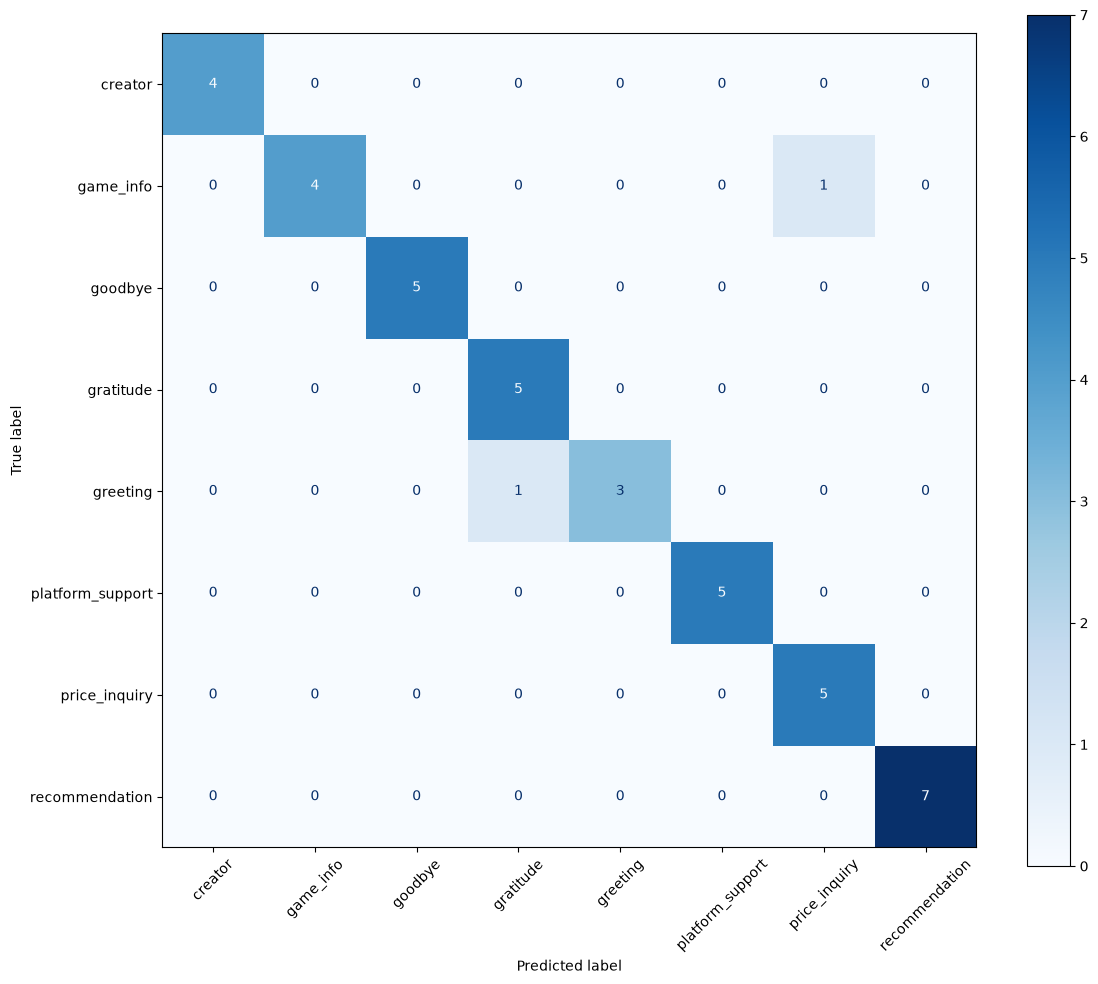

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    patterns, tags, test_size=0.2, random_state=42, stratify=tags
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred, zero_division=0))

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)

fig, ax = plt.subplots(figsize=(12, 10))

disp.plot(ax=ax, xticks_rotation=45, cmap="Blues")

plt.tight_layout()
plt.show()

In [ ]:
from nltk.translate.bleu_score import SmoothingFunction, sentence_bleu
from rouge_score import rouge_scorer

with open("data/eval_conversation.json", "r") as f:
    conversational_cases = json.load(f)

with open("data/eval_data.json", "r") as f:
    data_cases = json.load(f)

smooth = SmoothingFunction().method1
scorer = rouge_scorer.RougeScorer(["rouge1", "rougeL"], use_stemmer=True)

bleu_scores = []
rouge_1_scores = []
rouge_l_scores = []

for case in conversational_cases:
    generated_response = chat(case["input"])

    ref_tokens = [ref.lower().split() for ref in case["references"]]
    gen_tokens = generated_response.lower().split()

    bleu = sentence_bleu(
        ref_tokens, gen_tokens, weights=(0.5, 0.5, 0, 0), smoothing_function=smooth
    )
    bleu_scores.append(bleu)
    print(f"[Conversational] Input: '{case['input']}' | BLEU Score: {bleu:.4f}")

for case in data_cases:
    references = case["references"]
    generated_response = chat(case["input"])

    r1 = max(
        [scorer.score(ref, generated_response)["rouge1"].fmeasure for ref in references]
    )
    rl = max(
        [scorer.score(ref, generated_response)["rougeL"].fmeasure for ref in references]
    )

    rouge_1_scores.append(r1)
    rouge_l_scores.append(rl)
    print(
        f"[Data] Input: '{case['input']}' | ROUGE-1 F1: {r1:.4f} | ROUGE-L F1: {rl:.4f}"
    )

print("\n--- Final Evaluation Summary ---")
print(f"Mean Conversational BLEU-21: {np.mean(bleu_scores):.4f}")
print(f"Mean Data ROUGE-1 F1:     {np.mean(rouge_1_scores):.4f}")
print(f"Mean Data ROUGE-L F1:     {np.mean(rouge_l_scores):.4f}")

[Conversational] Input: 'hi' | BLEU Score: 0.5270
[Conversational] Input: 'hello' | BLEU Score: 0.4330
[Conversational] Input: 'who developed you' | BLEU Score: 1.0000
[Conversational] Input: 'thank you for helping' | BLEU Score: 0.0577
[Conversational] Input: 'close' | BLEU Score: 1.0000
[Conversational] Input: 'exit' | BLEU Score: 0.0358
[Data] Input: 'give me information on baldurs gate 3' | ROUGE-1 F1: 0.4222 | ROUGE-L F1: 0.3111
[Data] Input: 'info on baldurs gate 3' | ROUGE-1 F1: 0.4270 | ROUGE-L F1: 0.3596
[Data] Input: 'look up terraria' | ROUGE-1 F1: 0.4375 | ROUGE-L F1: 0.2813
[Data] Input: 'is terraria free' | ROUGE-1 F1: 0.6400 | ROUGE-L F1: 0.6400
[Data] Input: 'is Team Fortress 2 free to play?' | ROUGE-1 F1: 0.8750 | ROUGE-L F1: 0.8750
[Data] Input: 'is Manor Lords on sale?' | ROUGE-1 F1: 0.6667 | ROUGE-L F1: 0.6667
[Data] Input: 'does terraria support linux' | ROUGE-1 F1: 0.8750 | ROUGE-L F1: 0.7500
[Data] Input: 'can balatro run on windows' | ROUGE-1 F1: 0.6154 | ROUGE-

In [74]:
stop = False

while not stop:
    raw_input = input("You: ")
    print("You:", raw_input)

    clean_input = clean_text(raw_input)
    masked_input, title = mask_entities(clean_input)

    if not clean_input:
        continue

    intent = get_intent(masked_input)
    if intent is None:
        print(
            "Bot: I'm sorry, I didn't quite catch that. Could you try rephrasing your request?"
        )
        continue
    elif intent == "goodbye":
        stop = True

    print(f"Bot: Detected intent '{intent}'.")

    parsed_query = (
        parse_query(clean_input, title) if intent not in responses_lookup else None
    )
    response = handle_response(parsed_query, intent)

    print("Bot:", response)

You: portal 2
Bot: Detected intent 'game_info'.
Bot: Portal 2
Description: The 'Perpetual Testing Initiative' has been expanded to allow you to design co-op puzzles for you and your friends!
Price: $1.99  (80% off)
Developer(s): Valve
Genre(s): Action, Adventure
Rating Score: 98.7% (433510 reviews)
You: exit
Bot: Detected intent 'goodbye'.
Bot: Catch you later! Feel free to come back whenever you need game recommendations.
